In [1]:
import numpy as np
from pymdp.agent import Agent

In [2]:
# cell 1: grid / helper functions
n_rows, n_cols = 3, 3
n_cells = n_rows * n_cols         # 9
n_obs = 4                         # smell intensities 0..3
actions = ["up", "down", "left", "right", "stay"]
n_actions = len(actions)

def idx_to_rc(i):
    return divmod(i, n_cols)

def manhattan(i, j):
    ri, ci = idx_to_rc(i)
    rj, cj = idx_to_rc(j)
    return abs(ri - rj) + abs(ci - cj)


In [3]:
# cell 2: build A as pymdp expects (object array of modalities)
A_smell = np.zeros((n_obs, n_cells, n_cells))  # O x S_agent x S_cheese

for a in range(n_cells):         # agent position
    for c in range(n_cells):     # cheese position (unknown to agent)
        intensity = max(0, 3 - manhattan(a, c))
        A_smell[intensity, a, c] = 1.0        # deterministic

# pack into an object array (one modality)
A = np.empty(1, dtype=object)
A[0] = A_smell

# quick sanity
print("A_smell shape:", A_smell.shape)  # (4,9,9)
print("A type: ", A.dtype)


A_smell shape: (4, 9, 9)
A type:  object


In [4]:
# cell 3: build B object array (one element per hidden-state factor)
def idx_to_xy(idx):
    return (idx // n_cols, idx % n_cols)

def xy_to_idx(x, y):
    return x * n_cols + y

def step_from(idx, action):
    x, y = idx_to_xy(idx)
    if action == 0:   # up
        nx, ny = x-1, y
    elif action == 1: # down
        nx, ny = x+1, y
    elif action == 2: # left
        nx, ny = x, y-1
    elif action == 3: # right
        nx, ny = x, y+1
    elif action == 4: # stay
        nx, ny = x, y
    else:
        raise ValueError("bad action")
    # out-of-bounds => stay in place
    if nx < 0 or nx >= n_rows or ny < 0 or ny >= n_cols:
        return idx
    return xy_to_idx(nx, ny)

B = np.empty(2, dtype=object)

# build deterministic B for agent factor
B_agent = np.zeros((n_cells, n_cells, n_actions), dtype=float)

for s in range(n_cells):
    for a in range(n_actions):
        ns = step_from(s, a)
        B_agent[ns, s, a] = 1.0   # deterministic one-hot mapping

# sanity checks:
# each (s,a) column sums to 1
col_sums = B_agent.sum(axis=0)        # shape (n_cells, n_actions)
if not np.allclose(col_sums, 1.0):
    raise RuntimeError("B_agent columns not normalized - check construction")
print("B_agent constructed OK. shape:", B_agent.shape)

B[0] = B_agent

# factor 1: cheese transitions (static) -> shape (S_cheese_next, S_cheese_current, 1)
B_cheese = np.zeros((n_cells, n_cells, 1))
for s in range(n_cells):
    B_cheese[s, s, 0] = 1.0
B[1] = B_cheese

# factor lists describing dependencies
# A modality (smell) depends on both factors [agent, cheese]
A_factor_list = [[0, 1]]

# each B[f] depends on which hidden factors? (our agent factor depends on itself; cheese on itself)
B_factor_list = [[0], [1]]

print("B[0].shape (agent):", B[0].shape)   # (9,9,5)
print("B[1].shape (cheese):", B[1].shape)  # (9,9,1)
print(f'B[0] (agent): {B[0]}')

# test normalization: for each current_state s and action a,
# the vector B[:, s, a] should sum to 1
for a in range(B_agent.shape[2]):
    for s in range(B_agent.shape[1]):
        ssum = B_agent[:, s, a].sum()
        if not np.isclose(ssum, 1.0):
            print("BAD normalization: action", a, "cur_state", s, "sum=", ssum)
# test some sample entries:
s = 6; a = 1   # e.g. state 6, action 'down'
print("B[:, s, a] has a 1 at index:", np.nonzero(B_agent[:, s, a])[0])


B_agent constructed OK. shape: (9, 9, 5)
B[0].shape (agent): (9, 9, 5)
B[1].shape (cheese): (9, 9, 1)
B[0] (agent): [[[1. 0. 1. 0. 1.]
  [0. 0. 1. 0. 0.]
  [0. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 0. 0. 1. 0.]
  [1. 0. 0. 0. 1.]
  [0. 0. 1. 0. 0.]
  [0. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0.]
  [0. 0. 0. 1. 0.]
  [1. 0. 0. 1. 1.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 1. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 1. 0. 1.]
  [0. 0. 1. 0. 0.]
  [0. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0.]
  [0. 1. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 1. 0.]
  [0. 0. 0. 0. 1.]
  [0. 0. 1. 0. 0.]
  [0. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0.]


In [5]:
# cell 4: D priors (one per factor)
D = np.empty(2, dtype=object)

# agent prior: assume agent knows its own start (e.g., center=4). If you prefer unknown use uniform.
# D_agent = np.zeros(n_cells); D_agent[4] = 1.0   # start at center cell by default
D_agent = np.ones(n_cells)/n_cells           # alternative: unknown start

# cheese prior: unknown -> uniform
D_cheese = np.ones(n_cells) / n_cells

D[0] = D_agent
D[1] = D_cheese

print("D_agent sum:", D[0].sum(), "D_cheese sum:", D[1].sum())


D_agent sum: 1.0 D_cheese sum: 1.0


In [14]:
# cell 5: C (preference) as log-probabilities for smell modalities
def softmax(x):
    ex = np.exp(x - np.max(x))
    return ex / ex.sum()

U = np.array([-1.0, -1.0, -1.0, -1.0])   # utilities (0..3)
P_pref = softmax(U)                   # normalized pref
C = np.empty(1, dtype=object)
C[0] = np.log(P_pref)                 # store log-preferences (pymdp expects relative log probs)

print("C (log-pref):", C[0])


C (log-pref): [-1.38629436 -1.38629436 -1.38629436 -1.38629436]


In [ ]:
# cell 6 (replace): policies for horizon=1 (one timestep): include dummy control for cheese factor
# helper to generate all policies for given horizon (policy_len)
from itertools import product

def generate_policies(n_actions, n_control_factors, policy_len):
    """
    Generate all possible policies (sequences of actions) up to horizon=policy_len.
    Returns a list of arrays, each shape (policy_len, n_control_factors).
    For our setup: n_control_factors=2 (agent, cheese dummy).
    """
    policies = []
    for seq in product(range(n_actions), repeat=policy_len):
        pol = np.zeros((policy_len, n_control_factors), dtype=int)
        pol[:,0] = seq              # first column = agent actions
        # second column stays zeros (cheese control dummy)
        policies.append(pol)
    return policies

policy_len = 1

# now we have 2 control factors -> first is agent (5 actions), second is cheese (1 dummy action)
n_control_factors = 2

policies = generate_policies(n_actions, n_control_factors, policy_len)

print(len(policies))
# for p in policies:
#     print("policy shape:", p.shape, " ->", p)


5


In [8]:
print("B[0].shape (agent):", B[0].shape)
print("B[1].shape (cheese):", B[1].shape)
print("num_controls provided:", [n_actions, 1])
print("policy[0].shape:", policies[0].shape)


B[0].shape (agent): (9, 9, 5)
B[1].shape (cheese): (9, 9, 1)
num_controls provided: [5, 1]
policy[0].shape: (1, 2)


In [9]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import io
import imageio

def plot_grid(agent_pos, cheese_pos, visited, step):
    """Visualize 3x3 grid with mouse, cheese, and visited squares."""
    grid = np.zeros((3,3))

    fig, ax = plt.subplots(figsize=(3,3))

    # Draw squares
    for i in range(3):
        for j in range(3):
            idx = i*3 + j
            if idx == agent_pos:
                color = "blue"       # mouse
            elif idx == cheese_pos:
                color = "gold"       # cheese
            elif idx in visited:
                color = "lightgray"  # visited
            else:
                color = "white"      # unvisited
            ax.add_patch(plt.Rectangle((j, 2-i), 1, 1, facecolor=color, edgecolor="black"))

    # Formatting
    ax.set_xlim(0,3); ax.set_ylim(0,3)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"Step {step}")
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()


def render_grid_frame(agent_pos, cheese_pos, visited, step, cheese_posterior=None):
    """
    Render a 3x3 grid to an RGB numpy array (H x W x 3) by saving the Matplotlib
    figure to an in-memory PNG and reading it back. Ensures consistent image size
    and returns a fresh copy of the array.
    """
    # Create a figure with fixed size and dpi so saved PNGs are identical shape
    fig, ax = plt.subplots(figsize=(3,3), dpi=100)   # 300x300 px
    ax.set_xlim(0,3); ax.set_ylim(0,3)
    ax.set_xticks([]); ax.set_yticks([])
    plt.gca().set_aspect('equal', adjustable='box')
    ax.set_title(f"Step {step}")

    # Draw base squares
    for i in range(3):
        for j in range(3):
            idx = i*3 + j
            if idx == agent_pos:
                color = "blue"
            elif idx == cheese_pos:
                color = "gold"
            elif idx in visited:
                color = "lightgray"
            else:
                color = "white"
            ax.add_patch(plt.Rectangle((j, 2-i), 1, 1, facecolor=color, edgecolor="black"))

    # Overlay posterior heatmap (if provided)
    if cheese_posterior is not None:
        heat = np.array(cheese_posterior).reshape((3,3))
        ax.imshow(heat, extent=(0,3,0,3), origin='upper',
                  cmap='Reds', alpha=0.45, interpolation='nearest',
                  vmin=0, vmax=max(heat.max(), 1))

    # Save to in-memory PNG with a fixed canvas, *do not* use bbox_inches='tight'
    buf = io.BytesIO()
    fig.savefig(buf, format='png', facecolor=fig.get_facecolor())  # consistent size
    buf.seek(0)
    img = imageio.v2.imread(buf)   # H x W x 3 or H x W x 4
    buf.close()
    plt.close(fig)

    # Drop alpha channel if present, ensure dtype uint8
    if img.shape[-1] == 4:
        img = img[..., :3]

    # Return a copy to avoid any accidental shared-memory issues
    return img.copy()

Agent constructed.
agent.num_controls: [5, 1]
policy[0].shape: (1, 2) (T, n_hidden_factors)
true_cheese_pos: 8 true_agent_pos: 0

step 0 | true_agent=0 true_cheese=8 obs=0
  posterior cheese location (marginal): [0.   0.25 0.   0.25 0.   0.25 0.   0.25 0.  ]
  q(pi): [0.25 0.25 0.25 0.25 0.  ] neg_efe: [-0.206 -0.206 -0.206 -0.206 -0.822]
  chosen action index: 1 -> down

step 1 | true_agent=3 true_cheese=8 obs=0
  posterior cheese location (marginal): [0. 1. 0. 0. 0. 0. 0. 0. 0.]
  q(pi): [0.  0.  0.5 0.5 0. ] neg_efe: [-1.386 -1.386 -0.693 -0.693 -1.386]
  chosen action index: 2 -> left

step 2 | true_agent=3 true_cheese=8 obs=0
  posterior cheese location (marginal): [0. 1. 0. 0. 0. 0. 0. 0. 0.]
  q(pi): [0.2 0.2 0.2 0.2 0.2] neg_efe: [-1.386 -1.386 -1.386 -1.386 -1.386]
  chosen action index: 0 -> up

step 3 | true_agent=0 true_cheese=8 obs=0
  posterior cheese location (marginal): [0. 0. 1. 0. 0. 0. 0. 0. 0.]
  q(pi): [0.998 0.001 0.    0.001 0.001] neg_efe: [-0.288 -0.749 -1.385 

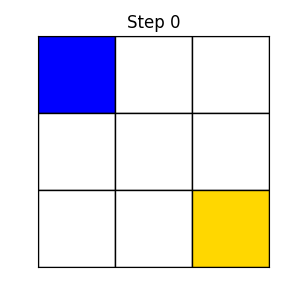

In [17]:
# cell 8 (replace): env + loop with visualization
import random
from IPython.display import Image, display

random.seed(41)
np.random.seed(0)

# cell 7 (replace): build the agent with correct control_fac_idx
# num_controls must list one entry per hidden-state factor (B shapes): [4, 1]
# control_fac_idx must list ONLY factors that are controllable (>1 actions) -> [0]
agent = Agent(
    A = A,
    B = B,
    C = C,
    D = D,
    policies = policies,
    policy_len = policy_len,
    num_controls = [n_actions, 1],   # one entry per hidden-state factor (agent, cheese)
    control_fac_idx = [0],           # only the agent factor (index 0) is controllable
    gamma = 16.0,       # policy precision
    alpha = 16.0,       # action selection precision
    use_utility = True,
    use_states_info_gain = True
)

print("Agent constructed.")
print("agent.num_controls:", agent.num_controls)
print("policy[0].shape:", agent.policies[0].shape, "(T, n_hidden_factors)")


true_agent_pos = 0
true_cheese_pos = 8
visited = {true_agent_pos}

print("true_cheese_pos:", true_cheese_pos, "true_agent_pos:", true_agent_pos)

def smell_intensity(agent_pos, cheese_pos):
    return max(0, 3 - manhattan(agent_pos, cheese_pos))

max_steps = 50
frames = []



for t in range(max_steps):
    # environment emits observation (integer 0..3)
    obs_int = int(smell_intensity(true_agent_pos, true_cheese_pos))

    # agent inference + action selection
    qs = agent.infer_states([obs_int])   # updates agent.qs
    q_pi, neg_efe = agent.infer_policies()
    sampled_actions = agent.sample_action()
    agent_action = int(sampled_actions[0])   # first factor = agent action

    # render frame AFTER inference so the posterior shown corresponds to current observation
    cheese_posterior = agent.qs[1].copy() if agent.qs is not None else None
    frame_img = render_grid_frame(true_agent_pos, true_cheese_pos, visited, t, cheese_posterior=cheese_posterior)
    frames.append(frame_img)

    print(f"\nstep {t} | true_agent={true_agent_pos} true_cheese={true_cheese_pos} obs={obs_int}")
    print("  posterior cheese location (marginal):", np.round(agent.qs[1], 3))
    print("  q(pi):", np.round(q_pi, 3), "neg_efe:", np.round(neg_efe, 3))
    print("  chosen action index:", agent_action, "->", actions[agent_action])

    # apply chosen action to the true agent (handle 'stay' if present)
    r, c = idx_to_rc(true_agent_pos)
    if agent_action == 0:   # up
        r2, c2 = max(r-1, 0), c
    elif agent_action == 1: # down
        r2, c2 = min(r+1, n_rows-1), c
    elif agent_action == 2: # left
        r2, c2 = r, max(c-1, 0)
    elif agent_action == 3: # right
        r2, c2 = r, min(c+1, n_cols-1)
    elif agent_action == 4: # stay (if present)
        r2, c2 = r, c
    true_agent_pos = r2 * n_cols + c2
    visited.add(true_agent_pos)

    # stop early if agent is on cheese
    # if true_agent_pos == true_cheese_pos:
    #     # add final frame showing arrival (posterior after final observation)
    #     frames.append(render_grid_frame(true_agent_pos, true_cheese_pos, visited, t+1, cheese_posterior=agent.qs[1]))
    #     print("Agent reached cheese! stopping.")
    #     break

gif_path = "run.gif"

imageio.mimsave(gif_path, frames, fps = 3)

print(f'Saved {gif_path}')

display(Image(gif_path))

In [11]:
import numpy as np

EPS = 1e-16

def softmax(x):
    x = np.array(x, dtype=float)
    x = x - np.max(x)
    e = np.exp(x)
    return e / (e.sum() + EPS)

def normalize(x):
    x = np.array(x, dtype=float)
    s = x.sum()
    if s == 0:
        return np.ones_like(x) / x.size
    return x / (s + EPS)

def _flatten_joint(q_factors):
    """Return flattened joint distribution vector and list of factor dims."""
    q_joint = q_factors[0].copy()
    for q in q_factors[1:]:
        q_joint = np.multiply.outer(q_joint, q).ravel()
    return q_joint

def _reshape_A_to_matrix(A_m):
    """Reshape an A modality A_m (n_obs, s1, s2, ...) -> (n_obs, n_joint_states)."""
    A_m = np.array(A_m, dtype=float)
    n_obs = A_m.shape[0]
    rest = A_m.shape[1:]
    n_joint = int(np.prod(rest))
    return A_m.reshape((n_obs, n_joint))

def compute_efe_components(A, B_list, policies, q0_factors, C, horizon=None):
    """
    Compute risk, ambiguity, epistemic and total EFE (G) for each policy.

    Args:
      A: list of modality likelihood tensors (A[m] shape: (n_obs_m, s1, s2, ...))
      B_list: list of transition tensors for each hidden factor
              B_list[f] shape: (n_s_f, n_s_f, n_controls_f)
      policies: either
                - list of arrays, each array shape (T, n_factors)  OR
                - numpy array of shape (n_policies, T, n_factors)
      q0_factors: list of current posterior marginals (one array per hidden factor)
      C: list of preference arrays per modality (each length n_obs_m), can be raw utilities
      horizon: number of steps to evaluate; if None uses policy length T

    Returns:
      dict with keys:
        'G','risk','ambiguity','epistemic'  -> arrays (n_policies,)
        'predicted_obs' -> list of length horizon of arrays (n_policies, n_obs_m) per modality
    """
    # Normalize inputs
    A = list(A)
    B_list = list(B_list)
    C = list(C)
    q0_factors = [normalize(q) for q in q0_factors]

    # Normalize preferences to probabilities
    C_probs = [softmax(c) for c in C]

    # Make policies into a list of policy arrays
    if isinstance(policies, np.ndarray):
        # shape may be (n_policies, T, n_factors)
        if policies.ndim == 3:
            policies_list = [policies[i] for i in range(policies.shape[0])]
        elif policies.ndim == 2:
            # single policy case: (T, n_factors)
            policies_list = [policies]
        else:
            raise ValueError("policies numpy array must be shape (n_policies, T, n_factors) or (T, n_factors)")
    elif isinstance(policies, list):
        policies_list = policies
    else:
        raise ValueError("policies must be a list or numpy array")

    n_policies = len(policies_list)
    # infer T and n_factors from first policy
    T, n_factors = policies_list[0].shape
    if horizon is None:
        horizon = T
    else:
        horizon = min(horizon, T)

    # Preprocess A modalities to (n_obs, n_joint_states)
    A_matrices = [_reshape_A_to_matrix(A_m) for A_m in A]
    n_obs_list = [Am.shape[0] for Am in A_matrices]
    n_joint_states = A_matrices[0].shape[1]

    # Keep results per policy
    G = np.zeros(n_policies)
    risk = np.zeros(n_policies)
    ambiguity = np.zeros(n_policies)
    epistemic = np.zeros(n_policies)
    # store predicted obs per modality per step: dict mod-> list of (n_policies, n_obs)
    predicted_obs_per_mod = {m: [] for m in range(len(A_matrices))}

    for p_idx, pol in enumerate(policies_list):
        # start from the current posterior marginals
        q_factors = [q.copy() for q in q0_factors]

        total_risk = 0.0
        total_ambiguity = 0.0
        total_epistemic = 0.0

        # evaluate across horizon steps
        for t in range(horizon):
            # get control per factor from policy at time t
            # policy array pol[t, f] is control index (integer)
            controls = [int(pol[t, f]) for f in range(n_factors)]

            # Predict next factor marginals under chosen actions
            q_next_factors = []
            for f in range(n_factors):
                Bf = np.array(B_list[f], dtype=float)  # (n_s, n_s, n_controls)
                u = controls[f]
                # Bf_slice: (n_s, n_s) with rows = next states, cols = prev states
                Bf_slice = Bf[:, :, u]
                q_prev = q_factors[f]
                q_next = Bf_slice.dot(q_prev)   # p(s_{t+1}) = sum_j B[i,j,u] q_prev[j]
                q_next = normalize(q_next)
                q_next_factors.append(q_next)

            # Build joint predicted state distribution (for time t+1)
            q_joint = _flatten_joint(q_next_factors)  # shape (n_joint_states,)

            # For each modality compute predicted obs, ambiguity, epistemic, risk
            for m, Amat in enumerate(A_matrices):
                # predicted obs distribution p(o) = Amat @ q_joint
                pred_o = Amat.dot(q_joint)  # shape (n_obs_m,)
                pred_o = normalize(pred_o)
                predicted_obs_per_mod[m].append(pred_o.copy())

                # RISK: -E_q[ log p_pref(o) ]  where p_pref = softmax(C_m)
                pref = C_probs[m]  # already normalized
                # avoid log(0)
                risk_m = -np.sum(pred_o * np.log(pref + EPS))

                # AMBIGUITY: E_s [ H[p(o|s)] ] = sum_s q_joint[s] * H(A[:, s])
                # compute entropies of columns of Amat
                # Amat shape (n_obs, n_joint_states) -> columns are p(o|s)
                col_probs = Amat.T  # shape (n_joint_states, n_obs)
                # entropy per joint state
                col_ent = -np.sum(col_probs * np.log(col_probs + EPS), axis=1)  # (n_joint_states,)
                ambiguity_m = np.sum(q_joint * col_ent)

                # EPISTEMIC: sum_o p(o) * KL[ p(s|o) || q_joint ]
                # p(s|o) ∝ p(o|s) q_joint[s]
                # compute p_o = pred_o (already)
                # compute posterior p(s|o) for each o
                # Amat shape (n_obs, n_joint_states)
                p_o_given_s = Amat  # (n_obs, n_joint_states)
                # p(s|o) = p(o|s) * q_joint[s] / p(o)
                # compute KL for each o
                kl_sum = 0.0
                for o_idx in range(p_o_given_s.shape[0]):
                    p_o = pred_o[o_idx]
                    if p_o < EPS:
                        continue
                    p_s_given_o = (p_o_given_s[o_idx, :] * q_joint)
                    denom = p_s_given_o.sum()
                    if denom == 0:
                        continue
                    p_s_given_o = p_s_given_o / (denom + EPS)
                    # KL(p_s_given_o || q_joint)
                    # protect zeros
                    kl = np.sum(p_s_given_o * (np.log(p_s_given_o + EPS) - np.log(q_joint + EPS)))
                    kl_sum += p_o * kl
                epistemic_m = kl_sum

                total_risk += risk_m
                total_ambiguity += ambiguity_m
                total_epistemic += epistemic_m

            # update q_factors to the predicted (for the next step)
            q_factors = q_next_factors

        # total expected free energy for this policy
        G[p_idx] = total_risk + total_ambiguity - total_epistemic
        risk[p_idx] = total_risk
        ambiguity[p_idx] = total_ambiguity
        epistemic[p_idx] = total_epistemic

    # convert predicted_obs_per_mod into lists of arrays with shape (horizon, n_policies, n_obs)
    predicted_obs_out = {}
    for m in predicted_obs_per_mod:
        # predicted_obs_per_mod[m] is length (horizon * n_policies) in the order we appended
        # We appended per policy, per t. So we can reshape
        arr = np.array(predicted_obs_per_mod[m])  # length n_policies * horizon, n_obs_m
        arr = arr.reshape((n_policies, horizon, arr.shape[-1]))
        predicted_obs_out[m] = arr  # shape (n_policies, horizon, n_obs_m)

    return {
        'G': G,
        'risk': risk,
        'ambiguity': ambiguity,
        'epistemic': epistemic,
        'predicted_obs': predicted_obs_out
    }


In [12]:
# Example - you must replace these names if your notebook uses different variable names:
# A: your likelihood (n_obs, n_agent_states, n_cheese_states)
# B: list [B_agent, B_cheese]
# policies_full: an array of candidate policies shaped either (T, n_policies, n_factors)
#                 or a single policy (T, n_factors)
# q0_factors: list of two arrays: [posterior_agent_marginal, posterior_cheese_marginal]
# C: your normalized outcome preference vector (n_obs,)
# horizon: how far ahead to evaluate (optional)

q_agent_marg = agent.qs[0]
q_cheese_marg = agent.qs[1]

res = compute_efe_components(
    A, B, policies,
    q0_factors=[q_agent_marg, q_cheese_marg],
    C=C,
    horizon=1
)

print("EFE components per policy:")
print("G:", np.round(res['G'], 3))
print("Risk:", np.round(res['risk'], 3))
print("Ambiguity:", np.round(res['ambiguity'], 3))
print("Epistemic:", np.round(res['epistemic'], 3))
print("Predicted obs per policy:", np.round(res['predicted_obs'][0], 3))



EFE components per policy:
G: [2.341 0.341 2.341 2.341 2.341]
Risk: [2.341 0.341 2.341 2.341 2.341]
Ambiguity: [0. 0. 0. 0. 0.]
Epistemic: [0. 0. 0. 0. 0.]
Predicted obs per policy: [[[0. 1. 0. 0.]]

 [[0. 0. 0. 1.]]

 [[0. 1. 0. 0.]]

 [[0. 0. 1. 0.]]

 [[0. 0. 1. 0.]]]
